# v0.1.1 first run — citation_retrieval

Loads a harness run, runs exact / fuzzy / (stub) semantic scorers, reports a Jeffreys posterior interval on exact-match rate, plots per-item results, and prints a summary table.

With n=5 items the interval will be wide — that is the point. What matters at v0.1.1 is that the pipeline (load → score → interval → plot → table) is real, so later expansions only change the inputs.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'benchmark').is_dir() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from harness.scoring import score_run

In [2]:
ITEMS_FILE = REPO_ROOT / 'benchmark' / 'tasks' / 'citation_retrieval' / 'items.jsonl'

candidates = sorted((REPO_ROOT / 'results' / 'raw').glob('*.jsonl'))
RUN_FILE = candidates[-1] if candidates else None

print('ITEMS_FILE:', ITEMS_FILE)
print('RUN_FILE:  ', RUN_FILE)
assert RUN_FILE is not None, (
    'No run file found under results/raw/. Run `python -m harness.run --items '
    'benchmark/tasks/citation_retrieval/items.jsonl` first.'
)

ITEMS_FILE: /Users/kylie-annerichards/projects/aus-reg-bench/benchmark/tasks/citation_retrieval/items.jsonl
RUN_FILE:   /Users/kylie-annerichards/projects/aus-reg-bench/results/raw/20260423T214644Z-anthropic.jsonl


In [3]:
df = score_run(RUN_FILE, ITEMS_FILE)
df

,item_id,model,provider,gold,response_text,input_tokens,output_tokens,exact_match_score,fuzzy_match_score,fuzzy_match_ratio,fuzzy_match_threshold,semantic_match_score,semantic_match_note
0,cr-001,claude-opus-4-7,anthropic,RG 168,RG 168,80,8,1.0,1.0,1.0,0.85,None,not implemented
1,cr-002,claude-opus-4-7,anthropic,RG 274,RG 274,85,8,1.0,1.0,1.0,0.85,None,not implemented
2,cr-003,claude-opus-4-7,anthropic,RG 104,RG 104,131,8,1.0,1.0,1.0,0.85,None,not implemented
3,cr-004,claude-opus-4-7,anthropic,RG 271,RG 271,112,8,1.0,1.0,1.0,0.85,None,not implemented
4,cr-005,claude-opus-4-7,anthropic,RG 272,RG 272,144,8,1.0,1.0,1.0,0.85,None,not implemented


In [4]:
def jeffreys_interval(k: int, n: int, alpha: float = 0.05):
    """Posterior credible interval for a binomial rate under a Jeffreys (Beta(1/2, 1/2)) prior."""
    a, b = k + 0.5, n - k + 0.5
    lo = 0.0 if k == 0 else stats.beta.ppf(alpha / 2, a, b)
    hi = 1.0 if k == n else stats.beta.ppf(1 - alpha / 2, a, b)
    mean = a / (a + b)
    return mean, lo, hi

n = len(df)
k = int(df['exact_match_score'].sum())
mean, lo, hi = jeffreys_interval(k, n)
print(f'Exact-match rate:        {k}/{n} = {k / n:.2%}')
print(f'Jeffreys posterior mean: {mean:.2%}')
print(f'95% credible interval:   [{lo:.2%}, {hi:.2%}]')

Exact-match rate:        5/5 = 100.00%
Jeffreys posterior mean: 91.67%
95% credible interval:   [62.06%, 100.00%]


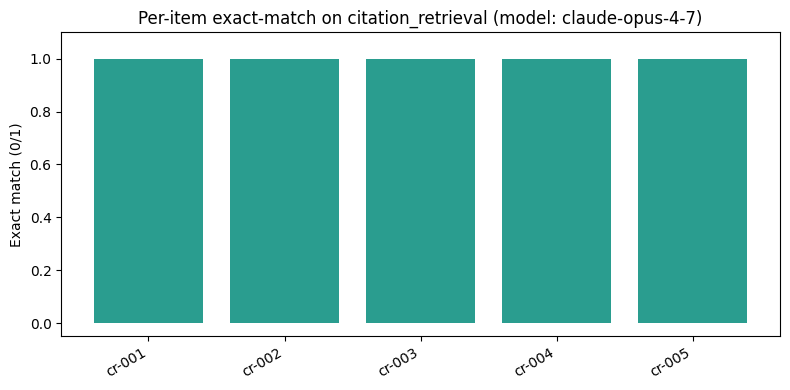

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2a9d8f' if s == 1.0 else '#e76f51' for s in df['exact_match_score']]
ax.bar(df['item_id'], df['exact_match_score'], color=colors)
ax.set_ylim(-0.05, 1.1)
ax.set_ylabel('Exact match (0/1)')
model_label = df['model'].iloc[0] if len(df) else 'unknown'
ax.set_title(f'Per-item exact-match on citation_retrieval (model: {model_label})')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [6]:
summary = df[['item_id', 'gold', 'response_text', 'exact_match_score', 'fuzzy_match_score', 'fuzzy_match_ratio']]
with pd.option_context('display.max_colwidth', 80):
    print(summary.to_string(index=False))

item_id   gold response_text  exact_match_score  fuzzy_match_score  fuzzy_match_ratio
 cr-001 RG 168        RG 168                1.0                1.0                1.0
 cr-002 RG 274        RG 274                1.0                1.0                1.0
 cr-003 RG 104        RG 104                1.0                1.0                1.0
 cr-004 RG 271        RG 271                1.0                1.0                1.0
 cr-005 RG 272        RG 272                1.0                1.0                1.0
